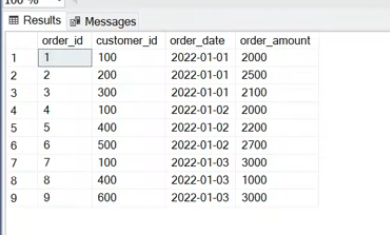

In [ ]:
with fv as (
select customer_id,min(order_date) as first_visit_date 
from cus_data group by customer_id
),visit_flag as(
select co.order_date,
case when co.order_date=fv.first_visit_date then 1 else 0 end as first_visit_flag,
case when co.order_date!=fv.first_visit_date then 1 else 0 end as repeat_visit_flag
from customer_order co 
inner join fv on co.customer_id=fv.customer_id
order by order_id
)
select order_date,sum(first_visit_flag) as new_customer,sum(repeat_visit_flag) as repeated_customers from visit_flag group by order_date